<a href="https://colab.research.google.com/github/KateVol99/fraud-analysis-project/blob/main/01_fraud_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

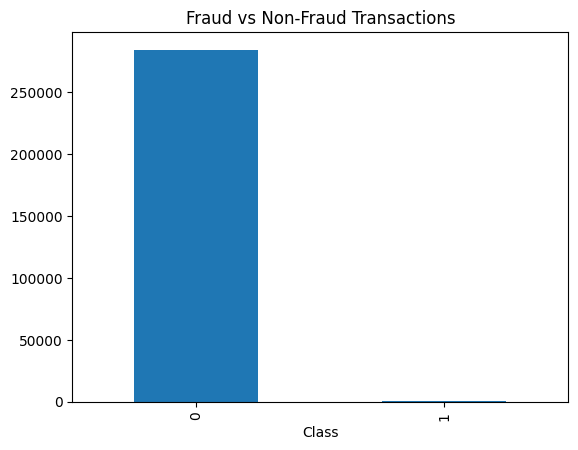

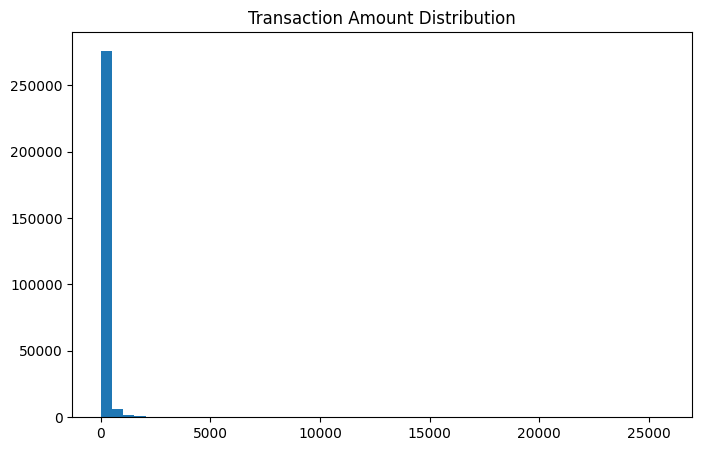

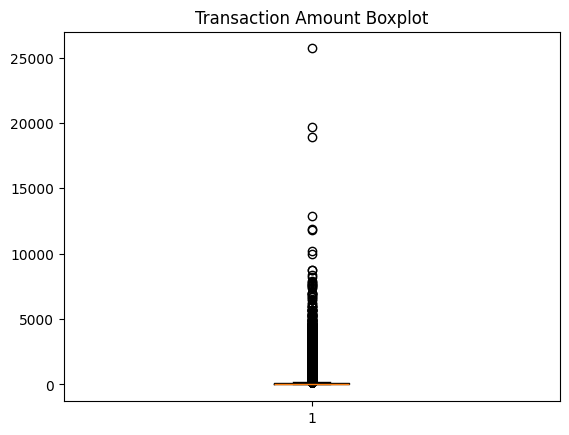

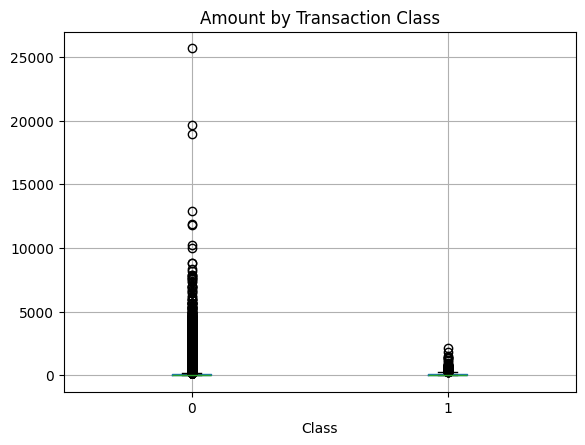

In [ ]:
# Load data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import shapiro, mannwhitneyu

df = pd.read_csv("/content/drive/MyDrive/creditcard.csv")

df.head()

# Data Quality Analysis

df.shape
df.info()

# Missing values
df.isnull().sum()
(df.isnull().mean() * 100).round(2)

# Duplicates
df.duplicated().sum()

# Exploratory Data Analysis (EDA)

df['Amount'].describe()
df.groupby('Class')['Amount'].describe()

# Outliers

Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]

print("Outliers count:", len(outliers))
print("Outliers %:", round(len(outliers) / len(df) * 100, 2))

df_clean = df.copy()

# Statistical analysis

fraud = df[df['Class'] == 1]['Amount']
normal = df[df['Class'] == 0]['Amount']

sample = df['Amount'].sample(5000, random_state=42)
stat, p_shapiro = shapiro(sample)

print("Shapiro p-value:", p_shapiro)

if p_shapiro < 0.05:
    print("Distribution is NOT normal")
else:
    print("Distribution is normal")


stat, p_mannwhitney = mannwhitneyu(
    fraud,
    normal,
    alternative='two-sided'
)

print("Mann-Whitney p-value:", p_mannwhitney)

if p_mannwhitney < 0.05:
    print("Significant difference between fraud and normal transactions")
else:
    print("No significant difference detected")


# Visualisation

df['Class'].value_counts().plot(kind='bar')
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df['Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.show()

plt.boxplot(df['Amount'])
plt.title('Transaction Amount Boxplot')
plt.show()

df.boxplot(column='Amount', by='Class')
plt.title('Amount by Transaction Class')
plt.suptitle('')
plt.show()